In [1]:
import random
import pandas as pd
import numpy as np
import biovec
import json
import seaborn as sns
import matplotlib.pyplot as plt
from Bio.SeqUtils import MeltingTemp as mt
from Bio.Seq import Seq
from itertools import product
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from biovec.models.duplex_vec import generate_complement


In [2]:
random.seed(42)

# Helper Functions

In [ ]:
def generate_random_dna_sequence(length: int) -> str:
    """Generate a random DNA sequence of given length."""
    return ''.join(np.random.choice(['A', 'T', 'C', 'G'], size=length))

def sample_dna_sequences(length: int, sample_size: int=4**8) -> list[str]:
    """Randomly sample DNA sequences of a given length with no duplicates."""
    max_seq = 4 ** length
    if sample_size > max_seq:
        raise ValueError(f"Cannot sample {sample_size} unique sequences, exceeds maximum possible sequences {max_seq}")
    
    # Generate unique sequences until sample size is reached.
    seqs = set()
    while len(seqs) < sample_size:
        seq = generate_random_dna_sequence(length)
        seqs.add(seq)
    return list(seqs)

def dna_complement(base: str) -> str:
    """Get the Watson-Crick complement of a DNA base."""
    complement = {
        'A': 'T',
        'T': 'A',
        'C': 'G',
        'G': 'C'
    }
    return complement.get(base, base)  # Return the base itself if not found

def random_mismatch_perturbation(sequence: str, num_mismatches: int=1) -> tuple[str, str]:
    """Introduce random mismatches in the sequence."""
    seq_list= list(sequence)
    comp_list = [dna_complement(base) for base in seq_list]
    length = len(seq_list)

    positions = np.random.choice(length, size=num_mismatches, replace=False) # Return numpy array of positions, 'replace' indicates no duplicates

    for i in positions:
        new_base = np.random.choice([b for b in 'ATCG' if b != dna_complement(seq_list[i])])
        comp_list[i] = new_base

    return ''.join(seq_list), ''.join(comp_list)

def generate_dna_sequences(length):
    """Generate a list of all DNA sequences of a given length."""
    return [''.join(seq) for seq in product('ATCG', repeat=length)]

def calculate_duplex_tm(top: str, bottom: str, Na=50, dnac1=50, dnac2=50, saltcorr=5):
    try:
        return mt.Tm_NN(seq=Seq(top), c_seq=Seq(bottom), 
            nn_table=mt.DNA_NN3,   # Allawi & SanaLucia (1997)(default)
            imm_table=mt.DNA_IMM1, # Internal Mismatches: SantaLucia & Peyret, 2001 (default)
            tmm_table=mt.DNA_TMM1, # Terminal Mismatches: (Allawi & SantaLucia, 1997-1998; Peyret et al., 1999; Watkins & SantaLucia, 2005) (default)
            de_table=mt.DNA_DE1,   # Dangling Ends: Bommarito et al. (2000) (default)
            Na=Na, dnac1=dnac1, dnac2=dnac2, saltcorr=saltcorr)
    except:
        return None


def generate_all_ngrams(n: int = 3) -> pd.DataFrame:
    """
    Creates a dataset of all Duplex(Top, Bottom) combinations of length n, 
    preventing missing tokens in downstream XGBoost analysis.

    Returns:
        pd.DataFrame with ["Top", "Bottom", "Mismatches", "Tm"]
    """
    bases = ["A", "C", "G", "T"]
    seqs = ["".join(p) for p in product(bases, repeat=n)]
    rows = []

    for top in tqdm(seqs, desc=f"Generating n={n} Duplexes", leave=True):
        for bottom in seqs:
            tm = calculate_duplex_tm(top, bottom)
            rows.append({
                "Top": top,
                "Bottom": bottom,
                "Mismatches": sum((a != b) for a, b in zip(top, bottom)),
                "Tm": tm
            })
    return pd.DataFrame(rows)

# Revamped Synthethic Dataset
def generate_synthetic_dataset(seq_len: int, mismatch_distribution: dict, n_gram: int) -> pd.DataFrame:
    """
    Generate synthetic dataset with:
      - No mismatches up to a given length, randomly sampled beyond a given threshold
      - A proportional number of mismatches per-length

    Args:
        seq_len (int): Length of sequences (e.g., 10 -> 4^10 top strands)
        mismatch_distribution: Proportion of mismatches to add per-length (e.g. {1: 0.3, 2: 0.2, 3: 0.1})
    Return:
        pd.DataFrame with ["Top", "Bottom", "Mismatches", "Tm"]
    """
        
    rows = []
    
    for length in range(1, seq_len + 1):
        if length <= 10:
            tops = generate_dna_sequences(length) # Enumerates all sequences of this length into a list
        else:
            tops = sample_dna_sequences(length, sample_size=4**8)

        n = len(tops)
        mismatch_count = {mismatches: int(n * frac) for mismatches, frac in mismatch_distribution.items()} # {1: 1000, 2: 300, 3: 700}
        total = n + sum(mismatch_count.values())  # perfect + mismatched

        with tqdm(total=total, desc=f"Generating sequences of length {length}", leave=True) as pbar:
            # Perfect Sequences
            for top in tops:
                bottom = ''.join(dna_complement(b) for b in top)
                tm = calculate_duplex_tm(top, bottom)
                rows.append({"Top": top, "Bottom": bottom, "Mismatches": 0, "Tm": tm})
                pbar.update(1)
            
            # Mismatched Sequences  
            np.random.shuffle(tops)      
            i = 0
            for mismatches, count in mismatch_count.items():
                for _ in range(count):
                    top = tops[i]
                    i += 1
                    top, bottom = random_mismatch_perturbation(top, mismatches)
                    tm = calculate_duplex_tm(top, bottom)
                    rows.append({"Top": top, "Bottom": bottom, "Mismatches": mismatches, "Tm": tm})
                    pbar.update(1)

    # Ensure minimum token coverage for downstream analysis
    df = pd.DataFrame(rows)
    df_coverage = generate_all_ngrams(n_gram)
    df = pd.concat([df, df_coverage]).drop_duplicates(
        subset=["Top", "Bottom"]
    ).reset_index(drop=True)
        
    return df

In [4]:
# Streamline File Management

def mismatch_distribution_to_str(mismatch_dict: dict) -> str:
  """Converts mismatch dictionary or distribution to a string representation."""
  return "_".join(f"m{mismatch}:{frac}" for mismatch, frac in sorted(mismatch_dict.items()))

def create_dataset_id(project_name: str, seq_len: int, mismatch_distribution: str, n_gram: int, seed: int) -> str:
  """Converts a dataset + parameters into a single ID."""
  return f"{project_name}_{seq_len}L_{mismatch_distribution_to_str(mismatch_distribution)}_n{n_gram}_Seed{seed}"

# def create_model_id(n: int, dim: int, window: int, min_count: int, workers: int):
#   """Converts a model + parameters into a single ID."""
#   return f"ModelParams_n{n}_dim{dim}_window{window}_min_count{min_count}_workers{workers}"
# def create_model_id(n: int, size: int, window: int, min_count: int, workers: int, **kwargs) -> str:
#     """
#     Generate a model identifier string based on key hyperparameters.
    
#     Args:
#         n (int): n-gram size
#         size (int): vector dimensionality
#         window (int): context window size
#         min_count (int): minimum word count threshold
#         workers (int): number of worker threads
#         **kwargs: additional parameters (ignored in ID)
    
# #     Returns:
# #         str: a formatted model ID string
# #     """
# #     return f"ModelParams_n{n}_size{size}_window{window}_mincount{min_count}_workers{workers}"
# def create_model_id(**p) -> str:
#     """
#     Build a model ID string from whatever hyperparams are provided.
#     Missing keys are simply skipped.
#     """
#     p = dict(p)  # don't mutate caller's dict
#     if "dim" in p and "size" not in p:  # allow dim alias
#         p["size"] = p.pop("dim")

#     ordered = ("n", "size", "window", "min_count", "workers", "sg", "negative", "hs", "alpha")
#     parts = [f"{k}{p[k]}" for k in ordered if k in p]
#     return "ModelParams_" + "_".join(parts)
# Path Routing
def create_model_id(n: int, size: int, window: int, min_count: int, workers: int, negative: int, alpha: float, sample: float, hs: int) -> str:
  """Converts a model + parameters into a single ID."""
  return f"ModelParams_n{n}_size{size}_window{window}_min_count{min_count}_workers{workers}_negative{negative}_alpha{alpha}_sample{sample}_hs{hs}"
from pathlib import Path
ROOT_FOLDER = Path("Artifacts")

def _create_directory(path: Path) -> Path:
  """Ensure the directory for a path is made and return the path."""
  path.mkdir(parents=True, exist_ok=True)
  return path

def build_dataset_paths(dataset_id: str) -> dict[str, Path]:
  base = _create_directory(ROOT_FOLDER / "Data" / dataset_id)
  return {
    "base": base,
    "raw": base / "raw.parquet",
    "meta": base / "meta.json"
  }

def build_model_paths(dataset_id: str, model_id: str) -> dict[str, Path]:
  base = _create_directory(ROOT_FOLDER / "Model" / dataset_id / model_id)
  return {
    "base": base,
    "model": base / "dv.model",
    "meta": base / "meta.json"
  }

def build_analysis_paths(train_dataset_id: str, model_id: str, encoding_dataset_id= str | None) -> dict[str, Path]:
  root = ROOT_FOLDER / "Analysis" / train_dataset_id / model_id

  if encoding_dataset_id is None or encoding_dataset_id == train_dataset_id:
    base = _create_directory(root)
  else:
    base = _create_directory(root / encoding_dataset_id)

  return {
    "base": base,
    "heatmap": base / "heatmap.png",
    "meta": base / "meta.json"
  }

# Use to write meta-data into JSON
def save_json(path: Path, obj: dict) -> None:
  path.parent.mkdir(parents=True, exist_ok=True)
  with open(path, "w", encoding="utf-8") as f:
    json.dump(obj, f, indent=2, ensure_ascii=False)

# Convenient way to query data and models in these nested folders
def load_dataset(dataset_id: str, which: str="raw") -> pd.DataFrame:
  dataPaths = build_dataset_paths(dataset_id)
  if which not in dataPaths:
    raise ValueError(f"Data not found, select from the following {list(dataPaths.keys())}")
  return pd.read_parquet(dataPaths[which])

def load_model(train_dataset_id: str, model_id: str):
  modelPaths = build_model_paths(train_dataset_id, model_id)
  return biovec.models.load_duplex_model(str(modelPaths["model"]))

In [5]:
def preprocess_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Drop NaN/negative Tm from DF + return summary statistics"""
    print("Shape Before Processing", df.shape)
    print("Count of Negative Melting Tm:", (df["Tm"] < 0).sum())
    df = df.dropna(subset=["Tm"]).reset_index(drop=True)
    df = df[df["Tm"] >= 0].reset_index(drop=True)

    print("Shape After Processing", df.shape)
    print("")
    print(df["Mismatches"].value_counts().sort_index())
    print("\nSummary Statistics")
    print(df["Tm"].describe())
    print("Dataset successfully processed!")
    return df

# Introduce Buckets
def generate_tm_buckets(df, start, stop, step):
  """
  Assign Tm to a bucket and return bucket labels + counts
  """
  bins = np.arange(start, stop + step, step)
  labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins) - 1)]
  df["Tm Bucket"] = pd.cut(df["Tm"], bins=bins, labels=labels)
  buckets = df["Tm Bucket"].dropna().unique().sort_values().tolist() # [0-10,10-20,30-40]
  return buckets

def bucket_summary(df: pd.DataFrame, buckets):
    print(df["Tm Bucket"].value_counts().reindex(buckets, fill_value=0))

def compute_bucket_similarity(df, vectors, buckets, sample_size=1000, random_state=42):
    """
    Compute approximate mean cosine similarity between Tm buckets
    using subsampling to avoid memory blowup.
    """
    rng = np.random.default_rng(random_state)

    # Normalize vectors once
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    normed = vectors / np.maximum(norms, 1e-12)

    n = len(buckets)
    matrix = np.full((n, n), np.nan)

    for i, b1 in enumerate(buckets):
        idx1 = df.index[df["Tm Bucket"] == b1].to_numpy()

        # Subsample if larger than given sample size
        if len(idx1) > sample_size:
            idx1 = rng.choice(idx1, sample_size, replace=False)

        # Compute within-bucket (diagonal)
        if len(idx1) > 1:  # need at least 2 to compute
            sims = np.dot(normed[idx1], normed[idx1].T)
            # Remove self-similarities (=1.0 on diagonal)
            mean_self = (sims.sum() - len(idx1)) / (len(idx1) * (len(idx1) - 1))
            matrix[i, i] = mean_self


        for j, b2 in enumerate(buckets[i+1:], start=i+1):
            idx2 = df.index[df["Tm Bucket"] == b2].to_numpy()
            if len(idx2) == 0 or len(idx1) == 0:
                continue
            if len(idx2) > sample_size:
                idx2 = rng.choice(idx2, sample_size, replace=False)

            # Compute similarity only on subsamples
            sims = np.dot(normed[idx1], normed[idx2].T).mean()
            matrix[i, j] = sims
            matrix[j, i] = sims

    return matrix

def run_model_analysis(df, dv_model, train_dataset_id: str, model_id: str, analysis_dataset_id: str | None, start: int, stop: int, step: int, sample_size: int = 1000, random_state: int = 42,):
    if analysis_dataset_id is None or analysis_dataset_id == train_dataset_id:
        effective_analysis_id = train_dataset_id
    else:
        effective_analysis_id = analysis_dataset_id
    
    analysisPaths = build_analysis_paths(train_dataset_id, model_id, analysis_dataset_id)
    vectors = dv_model.batch_encode(df)
    buckets = generate_tm_buckets(df, start, stop, step)
    sim_matrix = compute_bucket_similarity(df, vectors, buckets, sample_size, random_state)

    mask = np.tril(np.ones_like(sim_matrix, dtype=bool), k=-1)

    plt.figure(figsize=(8,6))
    sns.heatmap(sim_matrix, xticklabels=buckets, yticklabels=buckets, annot=True, fmt=".2f", mask=mask)
    title = (
        f"Cosine Similarity — {train_dataset_id}"
        if effective_analysis_id == train_dataset_id
        else f"Cosine Similarity — {train_dataset_id} → {effective_analysis_id}"
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(analysisPaths["heatmap"])
    plt.close()

    save_json(analysisPaths["meta"], {
        "train_dataset": train_dataset_id,
        "analysis_dataset": effective_analysis_id,
        "model_id": model_id,
        "buckets": buckets,
        "sample_size": sample_size,
        "random_state": random_state,
    })

    return analysisPaths

# Single Simulation Workflow

In [6]:
# FileName Convention: {ProjectName_[SeqLength]L_[MismatchDistribution]_Seed#.parquet}
# Example: PerfectDS_10L_m0:1.0_Seed42.parquet
# Example: Duplex_10L_m0:0.5_m1:0.5_Seed42.parquet

projectName = "Coverage"
seq_len = 10
mismatch_distribution = {1: 0.2, 2: 0.1}
seed = 42
n_gram = 3

df = generate_synthetic_dataset(seq_len=seq_len, mismatch_distribution=mismatch_distribution, n_gram=n_gram)

datasetID = create_dataset_id(projectName, seq_len, mismatch_distribution, n_gram, seed)
dataPaths = build_dataset_paths(datasetID) # returns dictionary of string -> path objects

df.to_parquet(dataPaths["raw"], engine="fastparquet", compression="snappy", index=False)
save_json(dataPaths["meta"], 
          { 
            "project": projectName,
            "seq_len": seq_len,
            "mismatch_distribution": mismatch_distribution,
            "n": n_gram,
            "seed": seed,
            "notes": "Includes n=3 trimer coverage, to avoid missing tokens in Oliveira dataset. Also sequenced up to 4^10 then randomly sample 4**8 afterwards"
            })

print(f'Saved dataset to: {dataPaths["raw"]}')
print(f'Saved dataset meta-data to: {dataPaths["meta"]}')

Generating n=3 Duplexes: 100%|██████████| 64/64 [00:00<00:00, 1344.35it/s]


Saved dataset to: Artifacts/Data/Coverage_10L_m1:0.2_m2:0.1_n3_Seed42/raw.parquet
Saved dataset meta-data to: Artifacts/Data/Coverage_10L_m1:0.2_m2:0.1_n3_Seed42/meta.json


In [7]:
# Query generated dataset, and apply post data-processing
df = load_dataset(datasetID)
print(df["Mismatches"].value_counts().sort_index())
print(df["Tm"].describe().apply(lambda x: format(x, 'f')))

# df = preprocess_dataset(df)

Mismatches
0    1398164
1     280191
2     141522
3       1657
Name: count, dtype: int64
count    1790315.000000
mean          15.364888
std           37.591884
min       -26890.589994
25%           10.770152
50%           19.592210
75%           26.077966
max         3974.450396
Name: Tm, dtype: str


In [ ]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- Tokenizers ---

def seq_to_ngrams(seq: str, n: int = 3) -> list[str]:
    seq = str(seq).upper()
    return [seq[i : i + n] for i in range(len(seq) - n + 1)]

def duplex_pair_tokens(top: str, bottom: str) -> list[str]:
    top = str(top).upper()
    bottom = str(bottom).upper()
    return [a + b for a, b in zip(top, bottom)]

def mean_pool(model: Word2Vec, tokens: list[str]) -> np.ndarray:
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)

def train_w2v(sentences, vector_size, window=5, min_count=1, sg=1, seed=42):
    return Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        workers=1,
        seed=seed,
        epochs=50,
    )

# --- Prepare corpora ---
n_gram = 3

top_sentences = [seq_to_ngrams(s, n_gram) for s in df["Top"]]
bottom_sentences = [seq_to_ngrams(s, n_gram) for s in df["Bottom"]]
pair_sentences = [duplex_pair_tokens(t, b) for t, b in zip(df["Top"], df["Bottom"])]

# --- Train three encoding schemes ---

# 1) Naive strand-wise encoding: 32-d top + 32-d bottom => 64-d
top_w2v = train_w2v(top_sentences, vector_size=32, window=5, min_count=1, sg=1)
bottom_w2v = train_w2v(bottom_sentences, vector_size=32, window=5, min_count=1, sg=1)

# 2) Cross-strand pair encoding: 64-d on positional base-pair tokens
pair_w2v = train_w2v(pair_sentences, vector_size=64, window=5, min_count=1, sg=1)

In [9]:
def encode_with_alignment(model, df):
    """Encode rows one-by-one and keep only rows that the model can encode."""
    vectors = []
    kept_idx = []

    for i, row in tqdm(enumerate(df.itertuples(index=False)), total=len(df), desc="Encoding rows"):
        top = str(row.Top).strip().upper()
        bottom = str(row.Bottom).strip().upper()

        try:
            vec = model.encode(top, bottom)
            vectors.append(vec)
            kept_idx.append(i)
        except Exception:
            # Skip rows that are invalid or not covered by the model vocabulary
            continue

    if not vectors:
        raise ValueError("No rows were successfully encoded by the DuplexVec model.")

    X = np.vstack(vectors)
    df_aligned = df.iloc[kept_idx].reset_index(drop=True)
    return X, df_aligned


# ...existing code...
# --- Encode dataframe with row-level alignment ---
X_duplex, df_aligned = encode_with_alignment(duplex_model, df)

# Drop rows with missing target (Tm) and re-align the DuplexVec embeddings
mask = df_aligned["Tm"].notna().to_numpy()
if not mask.all():
    print(f"Dropping {(~mask).sum()} rows with missing Tm before training")
    df_aligned = df_aligned[mask].reset_index(drop=True)
    X_duplex = X_duplex[mask]

# Now compute naive/pair encodings from the filtered df_aligned
X_naive = np.vstack([
    np.concatenate([
        mean_pool(top_w2v, seq_to_ngrams(t, n_gram)),
        mean_pool(bottom_w2v, seq_to_ngrams(b, n_gram)),
    ])
    for t, b in zip(df_aligned["Top"], df_aligned["Bottom"])
])

X_pair = np.vstack([
    mean_pool(pair_w2v, duplex_pair_tokens(t, b))
    for t, b in zip(df_aligned["Top"], df_aligned["Bottom"])
])

y = df_aligned["Tm"].to_numpy()

# sanity checks
assert X_duplex.shape[0] == X_naive.shape[0] == X_pair.shape[0] == len(y), "Feature/label length mismatch"
# ...existing code...

# --- Same split for all schemes ---
idx = np.arange(len(df_aligned))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

splits = {
    "Naive": (X_naive[train_idx], X_naive[test_idx]),
    "Pair": (X_pair[train_idx], X_pair[test_idx]),
    "DuplexVec": (X_duplex[train_idx], X_duplex[test_idx]),
}
y_train, y_test = y[train_idx], y[test_idx]

# --- XGBoost comparison ---
base_params = dict(
    random_state=42,
    objective="reg:squarederror",
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
)

results = {}
models = {}

for name, (X_train_s, X_test_s) in splits.items():
    model = XGBRegressor(**base_params)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
    }
    models[name] = model

results_df = pd.DataFrame(results).loc[["RMSE", "R2", "MAE"]]
print("\nXGBoost performance by encoding:")
print(results_df)

NameError: name 'duplex_model' is not defined

In [ ]:
def compute_sequence_features(top: str, bottom: str) -> dict:
    """
    Compute order-independent features from DNA duplex.
    Returns dict of engineered features.
    """
    top = str(top).upper()
    bottom = str(bottom).upper()
    
    features = {}
    
    # GC content (both strands)
    gc_top = (top.count('G') + top.count('C')) / len(top) if len(top) > 0 else 0
    gc_bottom = (bottom.count('G') + bottom.count('C')) / len(bottom) if len(bottom) > 0 else 0
    features['gc_top'] = gc_top
    features['gc_bottom'] = gc_bottom
    features['gc_mean'] = (gc_top + gc_bottom) / 2
    features['gc_diff'] = abs(gc_top - gc_bottom)
    
    # Mismatch count and fraction
    mismatches = sum(1 for a, b in zip(top, bottom) if a != b)
    features['mismatch_count'] = mismatches
    features['mismatch_frac'] = mismatches / len(top) if len(top) > 0 else 0
    
    # Homopolymer runs (longest consecutive identical bases)
    def max_homopolymer(seq):
        if not seq:
            return 0
        max_run = 1
        current_run = 1
        for i in range(1, len(seq)):
            if seq[i] == seq[i-1]:
                current_run += 1
                max_run = max(max_run, current_run)
            else:
                current_run = 1
        return max_run
    
    features['homopolymer_top'] = max_homopolymer(top)
    features['homopolymer_bottom'] = max_homopolymer(bottom)
    features['homopolymer_max'] = max(features['homopolymer_top'], features['homopolymer_bottom'])
    
    # Terminal base pair stability (end positions)
    def terminal_strength(a, b):
        """GC pairs (3 H-bonds) > AT pairs (2 H-bonds)"""
        if {a, b} == {'G', 'C'}:
            return 3
        elif {a, b} == {'A', 'T'}:
            return 2
        else:
            return 0  # mismatch
    
    features['terminal_5prime'] = terminal_strength(top[0], bottom[0])
    features['terminal_3prime'] = terminal_strength(top[-1], bottom[-1])
    features['terminal_sum'] = features['terminal_5prime'] + features['terminal_3prime']
    
    # Sequence length
    features['length'] = len(top)
    
    # AT/GC ratio
    at_top = (top.count('A') + top.count('T')) / len(top) if len(top) > 0 else 0
    features['at_ratio'] = at_top
    
    # Dinucleotide frequencies on top strand
    def dinuc_freq(seq, dinuc):
        if len(seq) < 2:
            return 0
        count = sum(1 for i in range(len(seq) - 1) if seq[i:i+2] == dinuc)
        return count / (len(seq) - 1)
    
    features['cg_freq_top'] = dinuc_freq(top, 'CG')
    features['gc_freq_top'] = dinuc_freq(top, 'GC')
    features['at_freq_top'] = dinuc_freq(top, 'AT')
    features['ta_freq_top'] = dinuc_freq(top, 'TA')
    features['aa_freq_top'] = dinuc_freq(top, 'AA')
    features['tt_freq_top'] = dinuc_freq(top, 'TT')
    features['gg_freq_top'] = dinuc_freq(top, 'GG')
    features['cc_freq_top'] = dinuc_freq(top, 'CC')
    
    # Duplex dinucleotide pair counts (e.g., AT-TA, GC-CG pairs across strands)
    def duplex_pair_freq(top_seq, bottom_seq, top_dinuc, bottom_dinuc):
        """Count how many positions have specific dinuc pairs across top/bottom strands"""
        if len(top_seq) < 2:
            return 0
        count = sum(1 for i in range(len(top_seq) - 1) 
                   if top_seq[i:i+2] == top_dinuc and bottom_seq[i:i+2] == bottom_dinuc)
        return count / (len(top_seq) - 1)
    
    # Common complementary pairs
    features['at_ta_pair'] = duplex_pair_freq(top, bottom, 'AT', 'TA')
    features['ta_at_pair'] = duplex_pair_freq(top, bottom, 'TA', 'AT')
    features['gc_cg_pair'] = duplex_pair_freq(top, bottom, 'GC', 'CG')
    features['cg_gc_pair'] = duplex_pair_freq(top, bottom, 'CG', 'GC')
    features['aa_tt_pair'] = duplex_pair_freq(top, bottom, 'AA', 'TT')
    features['tt_aa_pair'] = duplex_pair_freq(top, bottom, 'TT', 'AA')
    features['gg_cc_pair'] = duplex_pair_freq(top, bottom, 'GG', 'CC')
    features['cc_gg_pair'] = duplex_pair_freq(top, bottom, 'CC', 'GG')
    
    # Perfect complementary pairs (no mismatches at that position)
    perfect_pairs = sum(1 for a, b in zip(top, bottom) if b == dna_complement(a))
    features['perfect_pair_count'] = perfect_pairs
    features['perfect_pair_frac'] = perfect_pairs / len(top) if len(top) > 0 else 0
    
    return features

def encode_duplex_features(df: pd.DataFrame) -> np.ndarray:
    """Convert dataframe to feature matrix using engineered features."""
    feature_list = []
    
    for _, row in df.iterrows():
        feat_dict = compute_sequence_features(row['Top'], row['Bottom'])
        feature_list.append(feat_dict)
    
    # Convert to DataFrame, then numpy array
    features_df = pd.DataFrame(feature_list)
    return features_df.to_numpy()

# Usage in your pipeline:
X_engineered = encode_duplex_features(df_aligned)
print(f"Engineered feature matrix shape: {X_engineered.shape}")
print(f"Number of features: {X_engineered.shape[1]}")
sample_features = compute_sequence_features('ATGC', 'TACG')
print(f"Sample feature names: {list(sample_features.keys())}")

NameError: name 'df_aligned' is not defined

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, KFold

# --- Encode dataframe with engineered features ---
X_engineered = encode_duplex_features(df_aligned)

# Drop rows with missing target (Tm)
mask = df_aligned["Tm"].notna().to_numpy()
if not mask.all():
    print(f"Dropping {(~mask).sum()} rows with missing Tm before training")
    df_aligned = df_aligned[mask].reset_index(drop=True)
    X_engineered = X_engineered[mask]

y = df_aligned["Tm"].to_numpy()

assert X_engineered.shape[0] == len(y), "Feature/label length mismatch"

# --- Same split for comparison ---
idx = np.arange(len(df_aligned))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

X_train_eng = X_engineered[train_idx]
X_test_eng = X_engineered[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# --- Light hyperparameter tuning ---
base_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
)

param_distributions = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0],
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print("\n" + "=" * 60)
print("Tuning XGBoost on engineered features")
print("=" * 60)

search.fit(X_train_eng, y_train)

model_engineered = search.best_estimator_
pred_engineered = model_engineered.predict(X_test_eng)

results_engineered = {
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_engineered)),
    "R2": r2_score(y_test, pred_engineered),
    "MAE": mean_absolute_error(y_test, pred_engineered),
}

print("\nBest parameters:", search.best_params_)
print("\nEngineered Features Test Performance:")
print(f"  RMSE: {results_engineered['RMSE']:.4f}")
print(f"  R²:   {results_engineered['R2']:.4f}")
print(f"  MAE:  {results_engineered['MAE']:.4f}")


Tuning XGBoost on engineered features
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {'subsample': 0.9, 'reg_lambda': 2.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Engineered Features Test Performance:
  RMSE: 30.9279
  R²:   0.2190
  MAE:  2.7675


In [ ]:
# For self-analysis
buckets = generate_tm_buckets(df, start=0, stop=52, step=4)
bucket_summary(df, buckets)

In [ ]:
# Train a DuplexVec model from synthethic dataset

# Modify model parameters
n = 3
dim = 64
window = 3
sg = 1 # 1 skip-gram, 0 cbow
min_count = 1
workers = 3
negative = 5
alpha = 0.025
sample = 1e-3

modelID = create_model_id(n=n, size=dim, window=window, min_count=min_count, workers=workers, negative=negative, alpha=alpha, sample=sample, hs=0)
modelPaths = build_model_paths(dataset_id=datasetID, model_id=modelID)

dv = biovec.models.DuplexVec(
  df=df,
  n=n,
  size=dim,
  window=window,
  sg=sg,
  workers=workers,
  corpus_file=str(modelPaths["base"] / "corpus.txt"))

dv.save(str(modelPaths["model"]))
save_json(modelPaths["meta"], {
  "train_dataset": datasetID,
  "params": {
    "n": n, "dim": dim, "window": window, "min_count": min_count, "workers": workers
  }
})
print(f'Saved model to: {modelPaths["model"]}')


In [ ]:
dv_model = load_model(datasetID, modelID)

analysisPaths = run_model_analysis(
    df=df,
    dv_model=dv_model,
    train_dataset_id=datasetID,
    model_id=modelID,
    analysis_dataset_id=None,   # self-analysis
    start=0, stop=52, step=4
)

print(f"Analysis saved under {analysisPaths['base']}")

# Train Models with Different Hyperparameters (Single Dataset)

In [ ]:
datasetID = "Coverage_10L_m1:0.2_m2:0.1_n3_Seed42"
df = load_dataset(datasetID)
df = preprocess_dataset(df)
# * no Hierarchical Softmax
# * negative sampling: 4 vals [1-20] and 0
# * samples: 4 vals [.4e^-5, 1e^-5)
# * alpha: 4 vals [.021-.04]
# * window sizes (2,5,7)
# * BASELINE: 
#     * vector size: 32
#     * window: 7
#     * n = 3
#     * sg = 1
grid = [
  # Negative sampling sweep
  {"n": 3, "size": 32, "window": 7, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 1e-3, "negative": 21,  "hs": 1},
  {"n": 3, "size": 32, "window": 7, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 1e-3, "negative": 28, "hs": 1},
  {"n": 3, "size": 32, "window": 7, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 1e-3, "negative": 33, "hs": 1},
  {"n": 3, "size": 32, "window": 7, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 1e-3, "negative": 40, "hs": 1},

  # # Alpha sweep (neg=5, hs=0)
  # {"n": 3, "size": 32,   "window": 7, "min_count": 1, "workers": 3, "alpha": 0.021, "sample": 1e-3, "negative": 5, "hs": 1},
  # {"n": 3, "size": 32,   "window": 7, "min_count": 1, "workers": 3, "alpha": 0.027, "sample": 1e-3, "negative": 5, "hs": 1},
  # {"n": 3, "size": 32,   "window": 7, "min_count": 1, "workers": 3, "alpha": 0.033, "sample": 1e-3, "negative": 5, "hs": 1},
  # {"n": 3, "size": 32,   "window": 7, "min_count": 1, "workers": 3, "alpha": 0.040, "sample": 1e-3, "negative": 5, "hs": 1},

  # # Sample sweep (neg=5, hs=0)
  # {"n": 3, "size": 32,   "window": 7, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 4e-3,  "negative": 5, "hs": 1},
  # {"n": 3, "size": 32,   "window": 7, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 5.5e-3,"negative": 5, "hs": 1},
  # {"n": 3, "size": 32,   "window": 7, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 7e-3,  "negative": 5, "hs": 1},
  # {"n": 3, "size": 32,   "window": 7, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 8.5e-3,"negative": 5, "hs": 1},

  # # Window sweep (neg=5, hs=0)
  # {"n": 3, "size": 32,   "window": 2, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 1e-3, "negative": 5, "hs": 1},
  # {"n": 3, "size": 32,   "window": 5, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 1e-3, "negative": 5, "hs": 1},
  # {"n": 3, "size": 32,   "window": 7, "min_count": 1, "workers": 3, "alpha": 0.025, "sample": 1e-3, "negative": 5, "hs": 1},
]

for params in grid:
  modelID = create_model_id(**params)
  modelPaths = build_model_paths(datasetID, modelID)

  print(f"Training the following model: {modelID}.")

  dv = biovec.models.DuplexVec(
    df=df,
    n=params["n"],
    size=params["size"],
    window=params["window"],
    min_count=params["min_count"],
    workers=params["workers"],
    alpha=params.get("alpha", 0.025),
    negative=params["negative"],
    hs=params["hs"],
    sample=params.get("sample", 1e-3),   # <- float, not list
    corpus_file=str(modelPaths["base"] / "corpus.txt"),
)

  dv.save(str(modelPaths["model"]))
  save_json(modelPaths["meta"], {
    "train_dataset": datasetID,
    "params": params,
  })

  print("Model training complete. Running analysis...")

  run_model_analysis(
        df=df,
        dv_model=dv,
        train_dataset_id=datasetID,
        model_id=modelID,
        analysis_dataset_id=None,  # self-analysis
        start=0, stop=52, step=4
  )

  print(f"Analysis complete for {modelID}")


# XGBoost Regressor On Experimental Data

In [ ]:
from biovec.models.duplex_vec import generate_complement
df_dna = pd.read_csv("dna_melt_temp.csv")
df_dna["Top"] = df_dna["Sequence"].str.upper()
df_dna["Bottom"] = df_dna["Top"].apply(generate_complement)
df_dna = df_dna.rename(columns={"Experimental Temperature": "Tm"})
print(df_dna.shape)
df_dna.head()

(640, 8)


,Sequence,Oligo Concentration (M),Salt Concentration (M),pH,GC Content,Tm,Top,Bottom
0,CCGG,0.0001,1.0,7,1.0000,16.6,CCGG,GGCC
1,CGCG,0.0001,1.0,7,1.0000,23.7,CGCG,GCGC
2,GCGC,0.0001,1.0,7,1.0000,27.5,GCGC,CGCG
3,CCGCGG,0.0001,1.0,7,1.0000,55.2,CCGCGG,GGCGCC
4,CGATCG,0.0001,1.0,7,0.6667,34.3,CGATCG,GCTAGC


In [ ]:
df_oliveira = pd.read_csv('olveira.csv')

LEFT = "CGACGTGC"
RIGHT = "ATGTGCTG"

df_oliveira[["Top", "Bottom"]] = df_oliveira["Centre"].str.split("/", expand=True)
df_oliveira["Top"] = LEFT + df_oliveira["Top"] + RIGHT
df_oliveira["Bottom"] = generate_complement(LEFT) + df_oliveira["Bottom"] + generate_complement(RIGHT)
df_oliveira["Salt Concentration (M)"] = 0.06
df_oliveira = df_oliveira.rename(columns={"Temp Exp": "Tm"})
print(df_oliveira.shape)
df_oliveira.head()

(4096, 10)


,Unnamed: 0,i,Centre,Tm,Temp Pred,Melt Index,Mismatches,Top,Bottom,Salt Concentration (M)
0,0,1,GCG/CGC,69.3,71.47,3.8891,0,CGACGTGCGCGATGTGCTG,GCTGCACGCGCTACACGAC,0.06
1,1,2,CGC/GCG,69.1,69.73,3.8559,0,CGACGTGCCGCATGTGCTG,GCTGCACGGCGTACACGAC,0.06
2,2,3,GGC/CCG,68.9,69.73,3.8559,0,CGACGTGCGGCATGTGCTG,GCTGCACGCCGTACACGAC,0.06
3,3,4,GCC/CGG,68.7,69.73,3.8559,0,CGACGTGCGCCATGTGCTG,GCTGCACGCGGTACACGAC,0.06
4,4,5,CGG/GCC,68.2,70.50,3.8707,0,CGACGTGCCGGATGTGCTG,GCTGCACGGCCTACACGAC,0.06


In [ ]:
df = pd.concat(
  [df_dna, df_oliveira],
  ignore_index=True,
  sort=False
)
df["Salt Concentration (M)"] = df["Salt Concentration (M)"].fillna(0.06)
df["Oligo Concentration (M)"] = df["Oligo Concentration (M)"].fillna(1e-6)
print(df.shape)
df.head()

(4736, 14)


,Sequence,Oligo Concentration (M),Salt Concentration (M),pH,GC Content,Tm,Top,Bottom,Unnamed: 0,i,Centre,Temp Pred,Melt Index,Mismatches
0,CCGG,0.0001,1.0,7.0,1.0000,16.6,CCGG,GGCC,NaN,NaN,NaN,NaN,NaN,NaN
1,CGCG,0.0001,1.0,7.0,1.0000,23.7,CGCG,GCGC,NaN,NaN,NaN,NaN,NaN,NaN
2,GCGC,0.0001,1.0,7.0,1.0000,27.5,GCGC,CGCG,NaN,NaN,NaN,NaN,NaN,NaN
3,CCGCGG,0.0001,1.0,7.0,1.0000,55.2,CCGCGG,GGCGCC,NaN,NaN,NaN,NaN,NaN,NaN
4,CGATCG,0.0001,1.0,7.0,0.6667,34.3,CGATCG,GCTAGC,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def has_missing_tokens(seq, c_seq, missing, n=3):
    for i in range(len(seq) - n + 1):
        if (seq[i:i+n], c_seq[i:i+n]) in missing:
            return True
    return False

missing = {("AAT", "CAG"), ("AAT", "CAT")} # Need to debug for some reason these tokens aren't in the model already.
mask = df.apply(lambda row: has_missing_tokens(row["Top"], row["Bottom"], missing), axis=1)
df = df[~mask]
df.shape

(4734, 14)

In [ ]:
dv = load_model("Coverage_10L_m1:0.2_m2:0.1_n3_Seed42", 
                "ModelParams_n3_size64_window3_min_count1_workers3_negative5_alpha0.025_sample0.001_hs0")
X = dv.batch_encode(df)
y = df["Tm"].values
print(X.shape)
print(y.shape)
print("Single embedding:\n", X[:1])

Corpus generation progress: 100%|██████████| 4734/4734 [00:00<00:00, 14030.71it/s]

(4734, 64)
(4734,)
Single embedding:
 [[ 0.37932393 -0.1388857   0.10516164 -0.22238225 -0.27095082 -0.06702659
   0.0738004   0.18168417 -0.22244985  0.14999533  0.2891637  -0.28421807
  -0.29799968 -0.00871173 -0.14120856  0.29490012 -0.02136519  0.21164091
   0.02302976 -0.03772748  0.01528362  0.30788413  0.21963207 -0.16112313
   0.2042938   0.4338982  -0.08595963 -0.01205324  0.29996094 -0.12879606
   0.04448588  0.08863609 -0.01053297 -0.02015909  0.17103285 -0.17378148
  -0.04033183  0.01124739  0.1140656   0.42952722 -0.09204628  0.14482315
   0.02311547 -0.0485684   0.17117095 -0.02942332 -0.15321666 -0.07786985
   0.30957356 -0.12554973  0.08419143 -0.09801198  0.12871242  0.27527258
   0.23095906 -0.01926821 -0.04481705 -0.27336362  0.08525283  0.16933861
   0.03271694  0.08019075 -0.13757674  0.37202883]]


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for GridSearchCV (expanded; consider RandomizedSearch for speed)
param_grid = {
    'n_estimators': [50, 100, 100, 1000],
    'learning_rate': [0.01],
    'max_depth': [1,2,5,7],
    'min_child_weight': [1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.4],
    'reg_alpha': [0.1],
    'reg_lambda': [0.5, 1.0],
}

# Initialize base model with sensible defaults (use 'hist' for speed)
base_xgb = XGBRegressor(random_state=42, objective='reg:squarederror', tree_method='hist', n_jobs=-1)

# Create GridSearchCV
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

# Get best model
xgb = grid_search.best_estimator_
print("\nBest parameters:", grid_search.best_params_)
print("Best CV score (neg MSE):", grid_search.best_score_)

# Evaluate on test set
y_pred = xgb.predict(X_test)
print("\n" + "="*60)
print("Test Set Performance (Best Model)")
print("="*60)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# Show top 5 models from grid search
results_df_grid = pd.DataFrame(grid_search.cv_results_)
print("\n" + "="*60)
print("Top 5 Models from Grid Search")
print("="*60)
print(results_df_grid[['param_n_estimators', 'param_learning_rate', 'param_max_depth', 
                        'param_subsample', 'param_colsample_bytree', 'mean_test_score']].head())

Starting GridSearchCV...
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best parameters: {'colsample_bytree': 0.4, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 1000, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 1.0}
Best CV score (neg MSE): -13.293672803871967

Test Set Performance (Best Model)
RMSE: 3.5483511255212625
R²: 0.7953674547162825
MAE: 2.3236504716883237

Top 5 Models from Grid Search
   param_n_estimators  param_learning_rate  param_max_depth  param_subsample  \
0                  50                 0.01                1              0.6   
1                  50                 0.01                1              0.8   
2                  50                 0.01                1              1.0   
3                  50                 0.01                1              0.6   
4                  50                 0.01                1              0.8   

   param_colsample_bytree  mean_test_score  
0                    

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Simple Neural Network baseline for the DuplexVec embeddings
# Chosen architecture: 2 hidden layers with early stopping for a strong but compact baseline
nn = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size="auto",
        learning_rate_init=1e-3,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42,
    ),
)

print("=" * 60)
print("Training simple Neural Network baseline")
print("=" * 60)
print("Architecture: StandardScaler -> MLPRegressor(128, 64, relu, adam, early_stopping)")

nn.fit(X_train, y_train)

nn_pred = nn.predict(X_test)

nn_results = pd.DataFrame(
    {
        "NeuralNet": [
            root_mean_squared_error(y_test, nn_pred),
            r2_score(y_test, nn_pred),
            mean_absolute_error(y_test, nn_pred),
        ]
    },
    index=["RMSE", "R2", "MAE"],
)

print("\n" + "=" * 60)
print("Neural Network Test Performance")
print("=" * 60)
print(nn_results)


Training simple Neural Network baseline
Architecture: StandardScaler -> MLPRegressor(128, 64, relu, adam, early_stopping)

Neural Network Test Performance
      NeuralNet
RMSE   4.290905
R2     0.700760
MAE    2.847109


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, mean_absolute_error

# Use the best estimator from GridSearchCV
print("="*60)
print("Performance Analysis with Best XGBoost Estimator")
print("="*60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score (neg MSE): {grid_search.best_score_}")
print()

X_train2, X_test2, y_train2, y_test2, df_train, df_test = train_test_split(
    X, y, df, test_size=0.2, random_state=42
)

# Compute Biopython predictions and coerce failures to NaN
biopython_series = df_test.apply(
    lambda row: calculate_duplex_tm(row["Top"], row["Bottom"], Na=row["Salt Concentration (M)"] * 10**3, dnac1=row["Oligo Concentration (M)"] * 10**9, dnac2=row["Oligo Concentration (M)"] * 10**9, saltcorr=5), axis=1
)
biopython_pred = pd.to_numeric(biopython_series, errors="coerce").to_numpy()

# XGBoost predictions using the best estimator
xgb_pred = xgb.predict(X_test2)

# Build a comparison DataFrame and drop rows with any NaN before metric computation
results_df = pd.DataFrame({"y_true": y_test2, "xgb": xgb_pred, "biopython": biopython_pred})
before = len(results_df)
results_df = results_df.dropna(subset=["y_true", "xgb", "biopython"]).reset_index(drop=True)
dropped = before - len(results_df)
print(f"Dropped {dropped} rows with NaN predictions from comparison")

metrics = {
    "RMSE": lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    "R2": lambda y_true, y_pred: r2_score(y_true, y_pred),
    "MAE": lambda y_true, y_pred: mean_absolute_error(y_true, y_pred),
}

results = pd.DataFrame(
    {
        "XGBoost": [metrics[m](results_df["y_true"], results_df["xgb"]) for m in metrics],
        "Biopython": [metrics[m](results_df["y_true"], results_df["biopython"]) for m in metrics],
    },
    index=list(metrics.keys()),
)

print("\n" + "="*60)
print("Performance Metrics on Test Set")
print("="*60)
print(results)


Performance Analysis with Best XGBoost Estimator
Best parameters: {'colsample_bytree': 0.4, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 1000, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 1.0}
Best CV score (neg MSE): -13.293672803871967

Dropped 560 rows with NaN predictions from comparison

Performance Metrics on Test Set
       XGBoost  Biopython
RMSE  4.981035   3.197786
R2    0.785639   0.911650
MAE   3.446473   2.690359


In [ ]:
# Quick summary: exact test-set sizes and filtered comparison size
try:
    total = X.shape[0]
    t1 = X_test.shape[0]
    t2 = X_test2.shape[0]
    filtered = len(results_df) if 'results_df' in globals() else None

    print("="*50)
    print("Dataset size summary")
    print("="*50)
    print(f"Total samples (X): {total}")
    print(f"X_test size: {t1}")
    print(f"X_test2 size: {t2}")
    print(f"Filtered comparison size (results_df): {filtered}")
    print(f"X_test == X_test2 ? {t1 == t2}")
    print(f"Test fraction: {t1/total:.3f} (expected 0.2)")
    print("="*50)
except Exception as e:
    print("Could not compute sizes — missing variables or error:", e)


Dataset size summary
Total samples (X): 4734
X_test size: 947
X_test2 size: 947
Filtered comparison size (results_df): 387
X_test == X_test2 ? True
Test fraction: 0.200 (expected 0.2)


In [ ]:
# Compare performance on both X_test and X_test2 (should be identical splits)
print("=" * 60)
print("PERFORMANCE COMPARISON: X_test vs X_test2")
print("=" * 60)

# Get XGBoost predictions on X_test (from first split)
xgb_pred_test1 = xgb.predict(X_test)

# Get BioPython predictions for df_test rows
biopython_series_test1 = df_test.apply(
    lambda row: calculate_duplex_tm(row["Top"], row["Bottom"], Na=row["Salt Concentration (M)"] * 10**3, dnac1=row["Oligo Concentration (M)"] * 10**9, dnac2=row["Oligo Concentration (M)"] * 10**9, saltcorr=5), axis=1
)
biopython_pred_test1 = pd.to_numeric(biopython_series_test1, errors="coerce").to_numpy()

# Build comparison DataFrame for X_test
results_df_test1 = pd.DataFrame({"y_true": y_test, "xgb": xgb_pred_test1, "biopython": biopython_pred_test1})
before_test1 = len(results_df_test1)
results_df_test1 = results_df_test1.dropna(subset=["y_true", "xgb", "biopython"]).reset_index(drop=True)
dropped_test1 = before_test1 - len(results_df_test1)

print(f"\nX_test: Dropped {dropped_test1} rows with NaN predictions")
print(f"X_test2: Dropped {dropped} rows with NaN predictions")
print(f"\nSample sizes:")
print(f"  X_test after filtering: {len(results_df_test1)}")
print(f"  X_test2 after filtering: {len(results_df)}")

# Compute metrics for both
metrics_test1 = {
    "RMSE": lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    "R2": lambda y_true, y_pred: r2_score(y_true, y_pred),
    "MAE": lambda y_true, y_pred: mean_absolute_error(y_true, y_pred),
}

# X_test results
results_test1 = pd.DataFrame(
    {
        "XGBoost": [metrics_test1[m](results_df_test1["y_true"], results_df_test1["xgb"]) for m in metrics_test1],
        "Biopython": [metrics_test1[m](results_df_test1["y_true"], results_df_test1["biopython"]) for m in metrics_test1],
    },
    index=list(metrics_test1.keys()),
)

# X_test2 results (from previous cell)
results_test2 = pd.DataFrame(
    {
        "XGBoost": [metrics[m](results_df["y_true"], results_df["xgb"]) for m in metrics],
        "Biopython": [metrics[m](results_df["y_true"], results_df["biopython"]) for m in metrics],
    },
    index=list(metrics.keys()),
)

print("\n" + "=" * 60)
print("X_test Performance")
print("=" * 60)
print(results_test1)

print("\n" + "=" * 60)
print("X_test2 Performance")
print("=" * 60)
print(results_test2)

print("\n" + "=" * 60)
print("Difference (X_test - X_test2)")
print("=" * 60)
print(results_test1 - results_test2)


PERFORMANCE COMPARISON: X_test vs X_test2

X_test: Dropped 560 rows with NaN predictions
X_test2: Dropped 560 rows with NaN predictions

Sample sizes:
  X_test after filtering: 387
  X_test2 after filtering: 387

X_test Performance
       XGBoost  Biopython
RMSE  4.981035   3.197786
R2    0.785639   0.911650
MAE   3.446473   2.690359

X_test2 Performance
       XGBoost  Biopython
RMSE  4.981035   3.197786
R2    0.785639   0.911650
MAE   3.446473   2.690359

Difference (X_test - X_test2)
      XGBoost  Biopython
RMSE      0.0        0.0
R2        0.0        0.0
MAE       0.0        0.0


In [ ]:
# Compare XGBoost, NeuralNet, and Biopython on the same filtered test subset
print("="*60)
print("Model Comparison: XGBoost vs NeuralNet vs Biopython")
print("="*60)

# Predictions on X_test2
xgb_pred_test2 = xgb.predict(X_test2)
nn_pred_test2 = nn.predict(X_test2)

# biopython_pred was computed earlier for X_test2 (array); ensure it's a numeric Series
biopython_pred_test2 = pd.to_numeric(biopython_pred, errors="coerce")

# Build dataframe aligned to X_test2 / y_test2
df_models = pd.DataFrame({
    "y_true": y_test2,
    "XGBoost": xgb_pred_test2,
    "NeuralNet": nn_pred_test2,
    "Biopython": biopython_pred_test2,
})

before = len(df_models)
# Filter to rows where Biopython succeeded (match previous comparisons)
df_models = df_models.dropna(subset=["y_true", "Biopython"]).reset_index(drop=True)
dropped = before - len(df_models)
print(f"Dropped {dropped} rows where Biopython prediction was missing; using {len(df_models)} rows for comparison")

# Metrics
metrics = {
    "RMSE": lambda y, yhat: np.sqrt(mean_squared_error(y, yhat)),
    "R2": lambda y, yhat: r2_score(y, yhat),
    "MAE": lambda y, yhat: mean_absolute_error(y, yhat),
}

results_models = pd.DataFrame({
    "XGBoost": [metrics[m](df_models["y_true"], df_models["XGBoost"]) for m in metrics],
    "NeuralNet": [metrics[m](df_models["y_true"], df_models["NeuralNet"]) for m in metrics],
    "Biopython": [metrics[m](df_models["y_true"], df_models["Biopython"]) for m in metrics],
}, index=list(metrics.keys()))

print("\n" + "="*60)
print("Aggregate Metrics (filtered test set)")
print("="*60)
print(results_models)

print("\n" + "="*60)
print("Sample predictions (first 10 rows)")
print("="*60)
print(df_models[["y_true", "XGBoost", "NeuralNet", "Biopython"]].head(10))

# Optional: per-sample absolute error comparison for top 5 worst errors by XGBoost
df_models["err_xgb"] = np.abs(df_models["y_true"] - df_models["XGBoost"])
df_models["err_nn"] = np.abs(df_models["y_true"] - df_models["NeuralNet"])
df_models["err_bio"] = np.abs(df_models["y_true"] - df_models["Biopython"])

worst = df_models.sort_values("err_xgb", ascending=False).head(5)
print("\n" + "="*60)
print("Top 5 worst errors (by XGBoost) — show errors for all methods")
print("="*60)
print(worst[["y_true", "XGBoost", "NeuralNet", "Biopython", "err_xgb", "err_nn", "err_bio"]])


Model Comparison: XGBoost vs NeuralNet vs Biopython
Dropped 560 rows where Biopython prediction was missing; using 387 rows for comparison

Aggregate Metrics (filtered test set)
       XGBoost  NeuralNet  Biopython
RMSE  4.981035   6.054459   3.197786
R2    0.785639   0.683293   0.911650
MAE   3.446473   4.237731   2.690359

Sample predictions (first 10 rows)
   y_true    XGBoost  NeuralNet  Biopython
0    67.2  66.633698  67.247566  67.679939
1    55.7  54.867859  55.249786  52.739152
2    49.9  51.668850  50.576729  45.162845
3    53.7  62.867191  60.971416  57.240536
4    56.9  58.631554  59.364674  54.451308
5    53.8  51.483360  53.042622  50.103473
6    76.9  72.301132  72.850868  79.884605
7    51.4  51.862946  55.384998  48.452389
8    73.9  71.169304  71.306366  76.614669
9    58.7  57.267338  58.150452  57.028189

Top 5 worst errors (by XGBoost) — show errors for all methods
     y_true    XGBoost  NeuralNet  Biopython    err_xgb     err_nn   err_bio
199    33.2  54.596210  5

In [ ]:
# Show Top/Bottom sequences for the 5 worst XGBoost errors (on filtered subset)
try:
    # Recompute Biopython predictions if necessary and build valid mask
    biopython_series = df_test.apply(
        lambda row: calculate_duplex_tm(row["Top"], row["Bottom"], Na=row["Salt Concentration (M)"] * 10**3,
                                        dnac1=row["Oligo Concentration (M)"] * 10**9,
                                        dnac2=row["Oligo Concentration (M)"] * 10**9, saltcorr=5), axis=1)
    biopython_pred = pd.to_numeric(biopython_series, errors="coerce")
    valid_mask = biopython_pred.notna()

    # Align arrays to the filtered test set
    df_test_valid = df_test[valid_mask].reset_index(drop=True)
    X_test2_valid = X_test2[valid_mask.to_numpy()]
    y_test2_valid = y_test2[valid_mask.to_numpy()]

    # Predictions
    xgb_pred_valid = xgb.predict(X_test2_valid)
    nn_pred_valid = nn.predict(X_test2_valid)

    # Assemble DataFrame including sequences
    df_compare = pd.DataFrame({
        "Top": df_test_valid["Top"].values,
        "Bottom": df_test_valid["Bottom"].values,
        "y_true": y_test2_valid,
        "XGBoost": xgb_pred_valid,
        "NeuralNet": nn_pred_valid,
        "Biopython": biopython_pred[valid_mask].values,
    })

    df_compare["err_xgb"] = np.abs(df_compare["y_true"] - df_compare["XGBoost"]) 
    df_compare["err_nn"] = np.abs(df_compare["y_true"] - df_compare["NeuralNet"]) 
    df_compare["err_bio"] = np.abs(df_compare["y_true"] - df_compare["Biopython"]) 

    worst5 = df_compare.sort_values("err_xgb", ascending=False).head(5).reset_index(drop=True)

    print("Top 5 worst XGBoost errors (showing sequences and errors):")
    display(worst5[["Top", "Bottom", "y_true", "XGBoost", "NeuralNet", "Biopython", "err_xgb", "err_nn", "err_bio"]])

except Exception as e:
    print("Could not produce worst-error sequences:", e)


Top 5 worst XGBoost errors (showing sequences and errors):


,Top,Bottom,y_true,XGBoost,NeuralNet,Biopython,err_xgb,err_nn,err_bio
0,GTGAAC,CACTTG,33.2,54.596210,53.722122,33.343657,21.396210,20.522122,0.143657
1,TGATCA,ACTAGT,20.9,41.761147,33.532505,22.712292,20.861147,12.632505,1.812292
2,GCGCGC,CGCGCG,56.1,35.724442,35.974571,56.524147,20.375558,20.125429,0.424147
3,GTAGTAGTAG,CATCATCATC,29.6,49.130939,64.876259,27.090075,19.530939,35.276259,2.509925
4,TAGATCTA,ATCTAGAT,33.4,52.790245,54.446472,31.428190,19.390245,21.046472,1.971810


In [ ]:
# Compute top-5 worst errors for Biopython predictions and show sequences
try:
    # Recompute Biopython predictions for df_test (with unit conversions)
    biopython_series = df_test.apply(
        lambda row: calculate_duplex_tm(row["Top"], row["Bottom"], Na=row["Salt Concentration (M)"] * 10**3,
                                        dnac1=row["Oligo Concentration (M)"] * 10**9,
                                        dnac2=row["Oligo Concentration (M)"] * 10**9, saltcorr=5), axis=1)
    biopython_pred = pd.to_numeric(biopython_series, errors="coerce")
    valid_mask = biopython_pred.notna()

    # Align filtered test rows
    df_test_valid = df_test[valid_mask].reset_index(drop=True)
    X_test2_valid = X_test2[valid_mask.to_numpy()]
    y_test2_valid = y_test2[valid_mask.to_numpy()]

    # Predictions on valid rows
    xgb_pred_valid = xgb.predict(X_test2_valid)
    nn_pred_valid = nn.predict(X_test2_valid)

    # Build comparison DataFrame including sequences and errors
    df_compare = pd.DataFrame({
        "Top": df_test_valid["Top"].values,
        "Bottom": df_test_valid["Bottom"].values,
        "y_true": y_test2_valid,
        "XGBoost": xgb_pred_valid,
        "NeuralNet": nn_pred_valid,
        "Biopython": biopython_pred[valid_mask].values,
    })

    df_compare["err_xgb"] = np.abs(df_compare["y_true"] - df_compare["XGBoost"])
    df_compare["err_nn"] = np.abs(df_compare["y_true"] - df_compare["NeuralNet"])
    df_compare["err_bio"] = np.abs(df_compare["y_true"] - df_compare["Biopython"])

    # Top 5 worst by Biopython absolute error
    worst_bio = df_compare.sort_values("err_bio", ascending=False).head(5).reset_index(drop=True)

    print("Top 5 worst Biopython errors (showing sequences and errors):")
    display(worst_bio[["Top", "Bottom", "y_true", "XGBoost", "NeuralNet", "Biopython", "err_xgb", "err_nn", "err_bio"]])

except Exception as e:
    print("Could not produce Biopython worst-error sequences:", e)


Top 5 worst Biopython errors (showing sequences and errors):


,Top,Bottom,y_true,XGBoost,NeuralNet,Biopython,err_xgb,err_nn,err_bio
0,CGACGTGCGAAATGTGCTG,GCTGCACGATGTACACGAC,58.9,55.236839,56.746452,48.447044,3.663161,2.153548,10.452956
1,CGACGTGCGCAATGTGCTG,GCTGCACGAGGTACACGAC,60.2,58.648769,59.773403,50.652116,1.551231,0.426597,9.547884
2,CGACGTGCGACATGTGCTG,GCTGCACGATATACACGAC,54.5,52.471691,49.849716,46.619648,2.028309,4.650284,7.880352
3,CGACGTGCAGAATGTGCTG,GCTGCACGCCCTACACGAC,51.1,52.052536,59.940731,43.275260,0.952536,8.840731,7.824740
4,CGACGTGCGTAATGTGCTG,GCTGCACGAACTACACGAC,53.4,54.984997,47.346046,46.157941,1.584997,6.053954,7.242059


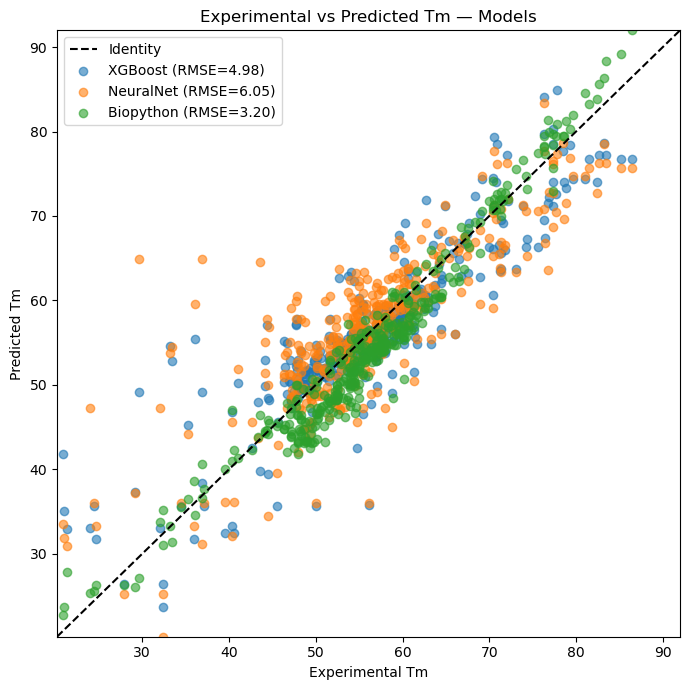

In [ ]:
# Plot Experimental vs Predicted for XGBoost, NeuralNet, Biopython
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

try:
    # Prefer df_compare or df_models if available
    if 'df_compare' in globals():
        df_plot = df_compare.copy()
    elif 'df_models' in globals():
        df_plot = df_models.copy()
    else:
        # Rebuild filtered comparison aligned to X_test2
        biopython_series = df_test.apply(
            lambda row: calculate_duplex_tm(row['Top'], row['Bottom'], Na=row['Salt Concentration (M)'] * 10**3, dnac1=row['Oligo Concentration (M)'] * 10**9, dnac2=row['Oligo Concentration (M)'] * 10**9, saltcorr=5), axis=1
        )
        biopython_pred = pd.to_numeric(biopython_series, errors='coerce')
        valid_mask = biopython_pred.notna()
        X_test2_valid = X_test2[valid_mask.to_numpy()]
        y_test2_valid = y_test2[valid_mask.to_numpy()]
        df_plot = pd.DataFrame({
            'y_true': y_test2_valid,
            'XGBoost': xgb.predict(X_test2_valid),
            'NeuralNet': nn.predict(X_test2_valid),
            'Biopython': biopython_pred[valid_mask].values,
        })

    # Compute RMSEs
    rmses = {}
    for col in ['XGBoost', 'NeuralNet', 'Biopython']:
        rmses[col] = np.sqrt(mean_squared_error(df_plot['y_true'], df_plot[col]))

    # Scatter plot overlay
    plt.figure(figsize=(7,7))
    mins = min(df_plot['y_true'].min(), df_plot[['XGBoost','NeuralNet','Biopython']].min().min())
    maxs = max(df_plot['y_true'].max(), df_plot[['XGBoost','NeuralNet','Biopython']].max().max())
    plt.plot([mins, maxs], [mins, maxs], 'k--', label='Identity')
    plt.scatter(df_plot['y_true'], df_plot['XGBoost'], alpha=0.6, label=f"XGBoost (RMSE={rmses['XGBoost']:.2f})")
    plt.scatter(df_plot['y_true'], df_plot['NeuralNet'], alpha=0.6, label=f"NeuralNet (RMSE={rmses['NeuralNet']:.2f})")
    plt.scatter(df_plot['y_true'], df_plot['Biopython'], alpha=0.6, label=f"Biopython (RMSE={rmses['Biopython']:.2f})")
    plt.xlabel('Experimental Tm')
    plt.ylabel('Predicted Tm')
    plt.title('Experimental vs Predicted Tm — Models')
    plt.xlim(mins, maxs)
    plt.ylim(mins, maxs)
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('Could not plot predictions:', e)


In [ ]:
# Two-model XGBoost ensemble + comparison to single XGBoost, NeuralNet, and Biopython
# Evaluated on the same split used above (X_test2 / y_test2 / df_test)

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


def is_mismatch_row(row):
    top = str(row["Top"]).upper()
    bottom = str(row["Bottom"]).upper()
    return bottom != generate_complement(top)


def metric_dict(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


# Recreate the same split if needed
if not all(v in globals() for v in ["X_train2", "X_test2", "y_train2", "y_test2", "df_train", "df_test"]):
    X_train2, X_test2, y_train2, y_test2, df_train, df_test = train_test_split(
        X, y, df, test_size=0.2, random_state=42
    )

# Build train/test mismatch masks
train_mismatch_mask = df_train.apply(is_mismatch_row, axis=1).to_numpy()
test_mismatch_mask = df_test.apply(is_mismatch_row, axis=1).to_numpy()
train_nomismatch_mask = ~train_mismatch_mask
test_nomismatch_mask = ~test_mismatch_mask

print("=" * 70)
print("Two-Model XGBoost Ensemble + Baseline Comparisons")
print("=" * 70)
print(f"Train: total={len(df_train)}, no-mismatch={train_nomismatch_mask.sum()}, mismatch={train_mismatch_mask.sum()}")
print(f"Test:  total={len(df_test)}, no-mismatch={test_nomismatch_mask.sum()}, mismatch={test_mismatch_mask.sum()}")

# Base params from best prior XGBoost model if available
if "xgb" in globals():
    print("Using best XGBoost model parameters from previous grid search for ensemble components")
    base_params = xgb.get_params()
else:
    base_params = dict(
        random_state=42,
        objective="reg:squarederror",
        tree_method="hist",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
    )

# Train ensemble components
fallback_model = XGBRegressor(**base_params)
fallback_model.fit(X_train2, y_train2)

model_nomismatch = None
if train_nomismatch_mask.sum() > 0:
    model_nomismatch = XGBRegressor(**base_params)
    model_nomismatch.fit(X_train2[train_nomismatch_mask], y_train2[train_nomismatch_mask])

model_mismatch = None
if train_mismatch_mask.sum() > 0:
    model_mismatch = XGBRegressor(**base_params)
    model_mismatch.fit(X_train2[train_mismatch_mask], y_train2[train_mismatch_mask])

# Ensemble prediction routing on SAME test split
y_pred_ensemble = np.empty_like(y_test2, dtype=float)

if test_nomismatch_mask.sum() > 0:
    nomodel = model_nomismatch if model_nomismatch is not None else fallback_model
    y_pred_ensemble[test_nomismatch_mask] = nomodel.predict(X_test2[test_nomismatch_mask])

if test_mismatch_mask.sum() > 0:
    mismodel = model_mismatch if model_mismatch is not None else fallback_model
    y_pred_ensemble[test_mismatch_mask] = mismodel.predict(X_test2[test_mismatch_mask])

# Other model predictions
pred_single_xgb = xgb.predict(X_test2) if "xgb" in globals() else fallback_model.predict(X_test2)
pred_nn = nn.predict(X_test2) if "nn" in globals() else np.full_like(y_test2, np.nan, dtype=float)

# Biopython predictions (may contain NaN)
biopython_series = df_test.apply(
    lambda row: calculate_duplex_tm(
        row["Top"],
        row["Bottom"],
        Na=row["Salt Concentration (M)"] * 10**3,
        dnac1=row["Oligo Concentration (M)"] * 10**9,
        dnac2=row["Oligo Concentration (M)"] * 10**9,
        saltcorr=5,
    ),
    axis=1,
)
pred_biopython = pd.to_numeric(biopython_series, errors="coerce").to_numpy()

# Build unified comparison table
df_eval = pd.DataFrame(
    {
        "y_true": y_test2,
        "Ensemble": y_pred_ensemble,
        "XGBoost": pred_single_xgb,
        "NeuralNet": pred_nn,
        "Biopython": pred_biopython,
    }
)

# Full-set metrics (excluding Biopython NaNs only for Biopython itself)
metrics_full = {
    "Ensemble": metric_dict(df_eval["y_true"], df_eval["Ensemble"]),
    "XGBoost": metric_dict(df_eval["y_true"], df_eval["XGBoost"]),
}
if np.isfinite(df_eval["NeuralNet"]).all():
    metrics_full["NeuralNet"] = metric_dict(df_eval["y_true"], df_eval["NeuralNet"])

bio_mask = pd.notna(df_eval["Biopython"]).to_numpy()
if bio_mask.sum() > 0:
    metrics_full["Biopython"] = metric_dict(df_eval.loc[bio_mask, "y_true"], df_eval.loc[bio_mask, "Biopython"])

results_full = pd.DataFrame(metrics_full).loc[["RMSE", "R2", "MAE"]]

# Fair comparison subset: rows where Biopython is valid
df_fair = df_eval.loc[bio_mask].reset_index(drop=True)
metrics_fair = {
    "Ensemble": metric_dict(df_fair["y_true"], df_fair["Ensemble"]),
    "XGBoost": metric_dict(df_fair["y_true"], df_fair["XGBoost"]),
    "Biopython": metric_dict(df_fair["y_true"], df_fair["Biopython"]),
}
if np.isfinite(df_fair["NeuralNet"]).all():
    metrics_fair["NeuralNet"] = metric_dict(df_fair["y_true"], df_fair["NeuralNet"])

results_fair = pd.DataFrame(metrics_fair).loc[["RMSE", "R2", "MAE"]]

print("\nFull test-set metrics (Biopython computed on its valid rows):")
print(results_full)
print(f"\nBiopython valid rows: {bio_mask.sum()} / {len(df_eval)}")

print("\nFair subset metrics (same rows where Biopython is valid):")
print(results_fair)

# Save for downstream use
ensemble_results = metrics_full.get("Ensemble", {})
ensemble_comparison_full = results_full
ensemble_comparison_fair = results_fair


Two-Model XGBoost Ensemble + Baseline Comparisons
Train: total=3787, no-mismatch=547, mismatch=3240
Test:  total=947, no-mismatch=157, mismatch=790
Using best XGBoost model parameters from previous grid search for ensemble components

Full test-set metrics (Biopython computed on its valid rows):
      Ensemble   XGBoost  NeuralNet  Biopython
RMSE  3.632586  3.548351   4.290905   3.197786
R2    0.785536  0.795367   0.700760   0.911650
MAE   2.346134  2.323650   2.847109   2.690359

Biopython valid rows: 387 / 947

Fair subset metrics (same rows where Biopython is valid):
      Ensemble   XGBoost  Biopython  NeuralNet
RMSE  5.111328  4.981035   3.197786   6.054459
R2    0.774278  0.785639   0.911650   0.683293
MAE   3.458022  3.446473   2.690359   4.237731


In [ ]:
from biovec.models.duplex_vec import generate_complement

# --- Load experimental dataset instead of artificial data ---
df = pd.read_csv("dna_melt_temp.csv")
df["Top"] = df["Sequence"].str.upper()
df["Bottom"] = df["Top"].apply(generate_complement)
df = df.rename(columns={"Experimental Temperature": "Tm"})

# Keep only valid rows
df = df.dropna(subset=["Tm"]).reset_index(drop=True)

print(df.shape)
print(df[["Top", "Bottom", "Tm"]].head())

# --- Encode dataframe with engineered features ---
X_engineered = encode_duplex_features(df)

y = df["Tm"].to_numpy()
assert X_engineered.shape[0] == len(y), "Feature/label length mismatch"

# --- Same split for comparison ---
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

X_train_eng = X_engineered[train_idx]
X_test_eng = X_engineered[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# --- Light hyperparameter tuning ---
base_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
)

param_distributions = {
    "n_estimators": [100, 200, 400, 600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0],
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

search.fit(X_train_eng, y_train)

model_engineered = search.best_estimator_
pred_engineered = model_engineered.predict(X_test_eng)

results_engineered = {
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_engineered)),
    "R2": r2_score(y_test, pred_engineered),
    "MAE": mean_absolute_error(y_test, pred_engineered),
}

print("Best parameters:", search.best_params_)
print(results_engineered)

(640, 8)
      Top  Bottom    Tm
0    CCGG    GGCC  16.6
1    CGCG    GCGC  23.7
2    GCGC    CGCG  27.5
3  CCGCGG  GGCGCC  55.2
4  CGATCG  GCTAGC  34.3


NameError: name 'RandomizedSearchCV' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from biovec.models.duplex_vec import generate_complement

# --- Reload experimental dataset to guarantee alignment ---
df_exp = pd.read_csv("dna_melt_temp.csv")
df_exp["Top"] = df_exp["Sequence"].str.upper()
df_exp["Bottom"] = df_exp["Top"].apply(generate_complement)
df_exp = df_exp.rename(columns={"Experimental Temperature": "Tm"})
df_exp = df_exp.dropna(subset=["Tm"]).reset_index(drop=True)

# --- Shared split ---
idx = np.arange(len(df_exp))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

df_test = df_exp.iloc[test_idx].reset_index(drop=True)
y_test = df_test["Tm"].to_numpy()

# --- Embedding features ---
# Uses your already-trained DuplexVec embedding pipeline
X_exp = X  # if X was created from df_exp in the experimental section
X_test_exp = X_exp[test_idx]

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
)
xgb.fit(X_exp[train_idx], df_exp["Tm"].to_numpy()[train_idx])

# --- Engineered features ---
X_engineered_exp = encode_duplex_features(df_exp)
X_test_eng = X_engineered_exp[test_idx]
# --- Predictions ---
preds = {
    "XGBoost-Embeddings": xgb.predict(X_test_exp),
    "NeuralNet-Embeddings": nn.predict(X_test_exp),
    "XGBoost-Engineered": model_engineered.predict(X_test_eng),
}

# Optional Biopython baseline on valid rows only
biopython_series = df_test.apply(
    lambda row: calculate_duplex_tm(
        row["Top"],
        row["Bottom"],
        Na=row["Salt Concentration (M)"] * 10**3 if "Salt Concentration (M)" in row else 50,
        dnac1=row["Oligo Concentration (M)"] * 10**9 if "Oligo Concentration (M)" in row else 50,
        dnac2=row["Oligo Concentration (M)"] * 10**9 if "Oligo Concentration (M)" in row else 50,
        saltcorr=5,
    ),
    axis=1,
)
biopython_pred = pd.to_numeric(biopython_series, errors="coerce").to_numpy()
preds["Biopython"] = biopython_pred

# --- Metric helper ---
def metric_row(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])),
        "R2": r2_score(y_true[mask], y_pred[mask]),
        "MAE": mean_absolute_error(y_true[mask], y_pred[mask]),
        "N": int(mask.sum()),
    }

# --- Build comparison table ---
comparison = pd.DataFrame({
    name: metric_row(y_test, pred)
    for name, pred in preds.items()
}).loc[["RMSE", "R2", "MAE", "N"]]

print("Experimental model comparison:")
print(comparison)

Experimental model comparison:
      XGBoost-Embeddings  NeuralNet-Embeddings  XGBoost-Engineered   Biopython
RMSE            7.344982              9.075259            7.312152    2.577435
R2              0.790764              0.680572            0.792630    0.974235
MAE             6.095586              7.009849            5.912679    1.762876
N             128.000000            128.000000          128.000000  128.000000
